In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
import joblib
import json
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

class MedAssistLocal:
    def __init__(self):
        print("Initializing MedAssist Local Engine...")
        # Define the base path for the data files
        base_path = '/content/drive/MyDrive/sml project/'

        # 1. Load the Model and Tools
        self.model = joblib.load(base_path + 'medassist_model_cpu.joblib')
        self.le = joblib.load(base_path + 'label_encoder.joblib')
        self.matrix = joblib.load(base_path + 'symptom_knowledge_matrix.joblib')
        # Load the saved test data
        self.X_test = np.load(base_path + 'Test data/X_test.npy')
        self.y_test = np.load(base_path + 'Test data/y_test.npy')

        # 2. Load the exact symptom list (order matters!)
        with open(base_path + 'symptom_list.json', 'r') as f:
            self.all_symptoms = json.load(f)

        print(f"System Ready. Loaded {len(self.all_symptoms)} symptoms and {len(self.le.classes_)} diseases.")

    def get_top_3(self, user_inputs):
        # Create input vector (377 zeros)
        input_vector = np.zeros(len(self.all_symptoms))

        # Set 1 for symptoms provided
        for s in user_inputs:
            if s in self.all_symptoms:
                idx = self.all_symptoms.index(s)
                input_vector[idx] = 1

        # Predict Probabilities
        probs = self.model.predict_proba([input_vector])[0]
        top_3_idx = np.argsort(probs)[-3:][::-1]

        results = []
        for idx in top_3_idx:
            disease = self.le.inverse_transform([idx])[0]
            confidence = probs[idx]
            results.append((disease, confidence))
        return results

    def suggest_follow_up(self, user_inputs, n=3):
        # Sum co-occurrence from the knowledge matrix
        scores = self.matrix[user_inputs].sum(axis=1)
        # Remove symptoms already mentioned
        scores = scores.drop(labels=user_inputs)
        return scores.sort_values(ascending=False).head(n).index.tolist()

    def run_Evaluation(self):
      # 1. Get standard Top-1 Predictions
      y_pred = self.model.predict(self.X_test)

      # 2. Get probabilities for Top-3 Accuracy
      probs = self.model.predict_proba(self.X_test)

      # 3. Calculate Top-1 Accuracy
      acc_top1 = accuracy_score(self.y_test, y_pred)

      # 4. Calculate Top-3 Accuracy
      # Check if the true label exists in the indices of the 3 highest probabilities
      top_3_indices = np.argsort(probs, axis=1)[:, -3:]
      correct_in_top3 = np.any(top_3_indices == self.y_test.reshape(-1, 1), axis=1)
      acc_top3 = np.mean(correct_in_top3)

      # 5. Get Macro F1-Score from classification report
      report = classification_report(self.y_test, y_pred, output_dict=True, zero_division=0)
      macro_f1 = report['macro avg']['f1-score']

      # Return as a dictionary for easy access in your simulation
      return {
          "top1_accuracy": acc_top1,
          "top3_accuracy": acc_top3,
          "macro_f1_score": macro_f1,
          "predictions": y_pred # Keep this in case you need to see what it guessed
      }


RUNNING THE LOCAL SYSTEM

In [30]:
if __name__ == "__main__":
    engine = MedAssistLocal()

    evaluation_results = engine.run_Evaluation()
    print("\n--- Model Evaluation Results (Full Test Set) ---")
    print(f"Top-1 Accuracy: {evaluation_results['top1_accuracy']*100:.2f}%")
    print(f"Top-3 Accuracy: {evaluation_results['top3_accuracy']*100:.2f}%")
    print(f"Macro F1-Score: {evaluation_results['macro_f1_score']:.2f}")

    # Example Interaction
    print("\n--- New Patient Session ---")
    # initial_symptoms = ['nose deformity', 'sore in nose', 'neck weakness']
    initial_symptoms = ['vomiting', 'fever']
    initial_predictions = engine.get_top_3(initial_symptoms)

    print("\nInitial Differential Diagnosis:")
    for i, (disease, conf) in enumerate(initial_predictions):
        print(f"{i+1}. {disease:<25} | Confidence: {conf*100:.2f}%")

    print(f"User reported: {initial_symptoms}")

    # 1. Get Suggestions
    suggestions = engine.suggest_follow_up(initial_symptoms)
    print(f"\n\nAI Suggestion: Are you also feeling {suggestions}?")

    # 2. Get Diagnosis
    # Let's assume the user confirmed 'abdominal pain'
    final_input = initial_symptoms + ['cough','nausea']
    final_predictions = engine.get_top_3(final_input)

    print("\nFinal Differential Diagnosis:")
    for i, (disease, conf) in enumerate(final_predictions):
        print(f"{i+1}. {disease:<25} | Confidence: {conf*100:.2f}%")

Initializing MedAssist Local Engine...
System Ready. Loaded 377 symptoms and 475 diseases.

--- Model Evaluation Results (Full Test Set) ---
Top-1 Accuracy: 87.08%
Top-3 Accuracy: 96.46%
Macro F1-Score: 0.88

--- New Patient Session ---

Initial Differential Diagnosis:
1. otitis media              | Confidence: 7.40%
2. urinary tract infection   | Confidence: 6.47%
3. acute bronchospasm        | Confidence: 5.42%
User reported: ['vomiting', 'fever']


AI Suggestion: Are you also feeling ['cough', 'nausea', 'sharp abdominal pain']?

Final Differential Diagnosis:
1. meningitis                | Confidence: 67.61%
2. white blood cell disease  | Confidence: 10.90%
3. flu                       | Confidence: 9.16%


In [14]:
initial_confidences = [conf for _, conf in initial_predictions]
average_initial_confidence = sum(initial_confidences) / len(initial_confidences)

final_confidences = [conf for _, conf in final_predictions]
average_final_confidence = sum(final_confidences) / len(final_confidences)

average_confidence_gain = average_final_confidence - average_initial_confidence

print(f"Average Initial Top-3 Confidence: {average_initial_confidence*100:.2f}%")
print(f"Average Final Top-3 Confidence: {average_final_confidence*100:.2f}%")
print(f"Average Confidence Gain: {average_confidence_gain*100:.2f}%")

Average Initial Top-3 Confidence: 3.33%
Average Final Top-3 Confidence: 6.61%
Average Confidence Gain: 3.27%


In [17]:
base_path = '/content/drive/MyDrive/sml project/'

# 1. Load the Model and Tools
model = joblib.load(base_path + 'medassist_model_cpu.joblib')
le = joblib.load(base_path + 'label_encoder.joblib')
matrix = joblib.load(base_path + 'symptom_knowledge_matrix.joblib')
# Load the saved test data
X_test = np.load(base_path + 'Test data/X_test.npy')
y_test = np.load(base_path + 'Test data/y_test.npy')

# 2. Load the exact symptom list (order matters!)
with open(base_path + 'symptom_list.json', 'r') as f:
    all_symptoms = json.load(f)

print(f"System Ready. Loaded {len(all_symptoms)} symptoms and {len(le.classes_)} diseases.")

System Ready. Loaded 377 symptoms and 475 diseases.


In [21]:
import numpy as np
from tqdm.notebook import tqdm

# Ensure the engine is instantiated. Assuming MedAssistLocal class and its dependencies
# (joblib, json, numpy, pandas, sklearn) are available from previously executed cells.
# 'engine' should be available from cell KQFqJezUblXN if it was executed.
# 'X_test' and 'all_symptoms' should be available from cell 5ngayD8tc49_.
if 'engine' not in locals():
    print("Instantiating MedAssistLocal engine...")
    engine = MedAssistLocal()

all_confidence_gains = []
# We will now take the first TWO suggested symptoms
num_suggested_symptoms_to_add = 2

# Iterate through each test case in X_test with a progress bar
for i in tqdm(range(len(X_test)), desc="Processing Test Cases"):
    # Get the indices of the symptoms present in the current test case
    symptom_indices_for_case = np.where(X_test[i] == 1)[0]

    # Skip test cases with fewer than 2 initial symptoms
    if len(symptom_indices_for_case) < 2:
        continue

    # Take the first 2 symptoms as initial symptoms for this test case
    initial_symptoms_names = [all_symptoms[idx] for idx in symptom_indices_for_case[:2]]

    # Get initial predictions (Top 3 diseases and their confidences)
    initial_predictions = engine.get_top_3(initial_symptoms_names)
    initial_confidences = [conf for _, conf in initial_predictions]

    if not initial_confidences:
        # Skip if no initial predictions were made
        continue

    average_initial_confidence = sum(initial_confidences) / len(initial_confidences)

    # Get suggested follow-up symptoms based on the initial symptoms
    suggestions = engine.suggest_follow_up(initial_symptoms_names)

    if not suggestions:
        # Skip if no suggestions are made
        continue

    # Select the first 'num_suggested_symptoms_to_add' suggested symptoms
    selected_suggested_symptoms = []
    if len(suggestions) >= num_suggested_symptoms_to_add:
        selected_suggested_symptoms = suggestions[:num_suggested_symptoms_to_add]
    else:
        # Skip if not enough suggestions were made to pick the chosen number
        continue

    # Form the final list of symptoms by adding the selected suggested symptoms
    final_symptoms_names = initial_symptoms_names + selected_suggested_symptoms

    # Get final predictions with the added symptoms
    final_predictions = engine.get_top_3(final_symptoms_names)
    final_confidences = [conf for _, conf in final_predictions]

    if not final_confidences:
        # Skip if no final predictions were made
        continue

    average_final_confidence = sum(final_confidences) / len(final_confidences)

    # Calculate the confidence gain for this specific test case
    confidence_gain = average_final_confidence - average_initial_confidence
    all_confidence_gains.append(confidence_gain)

# Calculate the overall average confidence gain across all valid test cases
if all_confidence_gains:
    overall_average_confidence_gain = sum(all_confidence_gains) / len(all_confidence_gains)
    print(f"Overall Average Confidence Gain across {len(all_confidence_gains)} valid test cases (with {num_suggested_symptoms_to_add} suggested symptoms added): {overall_average_confidence_gain*100:.2f}%")
else:
    print("No valid test cases found to calculate average confidence gain after filtering.")

Processing Test Cases:   0%|          | 0/47889 [00:00<?, ?it/s]

Overall Average Confidence Gain across 47829 valid test cases (with 2 suggested symptoms added): 7.54%


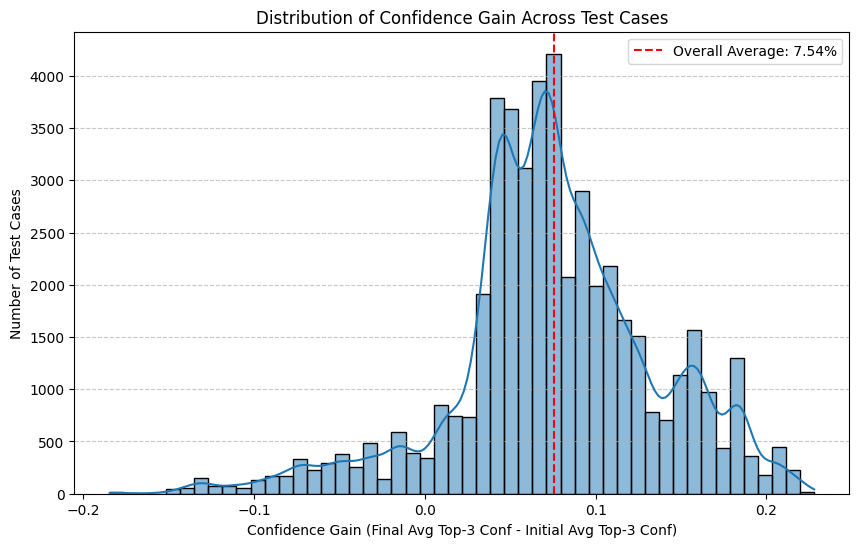

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out any NaN values or extremely large/small outliers if they exist, though unlikely for confidence gains
valid_confidence_gains = [g for g in all_confidence_gains if not np.isnan(g)]

plt.figure(figsize=(10, 6))
sns.histplot(valid_confidence_gains, bins=50, kde=True)
plt.title('Distribution of Confidence Gain Across Test Cases')
plt.xlabel('Confidence Gain (Final Avg Top-3 Conf - Initial Avg Top-3 Conf)')
plt.ylabel('Number of Test Cases')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axvline(x=overall_average_confidence_gain, color='r', linestyle='--', label=f'Overall Average: {overall_average_confidence_gain*100:.2f}%')
plt.legend()
plt.show()

In [23]:
highest_confidence_gain = max(valid_confidence_gains)
print(f"Highest Confidence Gain for a single case: {highest_confidence_gain*100:.2f}%")

Highest Confidence Gain for a single case: 22.79%


In [24]:
import numpy as np

highest_confidence_gain_unfiltered = np.max(all_confidence_gains)
print(f"Highest Confidence Gain (unfiltered, ignoring NaN): {highest_confidence_gain_unfiltered*100:.2f}%")

Highest Confidence Gain (unfiltered, ignoring NaN): 22.79%


In [25]:
import numpy as np

# Ensure the engine is instantiated. (Copied from yEw5uqZHc_1F for robustness)
if 'engine' not in locals():
    print("Instantiating MedAssistLocal engine...")
    engine = MedAssistLocal()

# Retrieve the highest confidence gain value (from previous cell execution)
highest_confidence_gain_value = highest_confidence_gain_unfiltered

# Ensure num_suggested_symptoms_to_add is available (it's 2 from previous context)
# If it's not in locals, default to 2.
if 'num_suggested_symptoms_to_add' not in locals():
    num_suggested_symptoms_to_add = 2

found_case_details = None

print(f"Searching for the test case that resulted in the highest confidence gain: {highest_confidence_gain_value*100:.2f}%")

# Iterate through each test case in X_test
for i in range(len(X_test)):
    # Get the indices of the symptoms present in the current test case
    symptom_indices_for_case = np.where(X_test[i] == 1)[0]

    # Skip test cases with fewer than 2 initial symptoms (as per original logic)
    if len(symptom_indices_for_case) < 2:
        continue

    # Take the first 2 symptoms as initial symptoms for this test case
    initial_symptoms_names = [all_symptoms[idx] for idx in symptom_indices_for_case[:2]]

    # Get initial predictions
    initial_predictions = engine.get_top_3(initial_symptoms_names)
    initial_confidences = [conf for _, conf in initial_predictions]

    if not initial_confidences:
        continue

    average_initial_confidence = sum(initial_confidences) / len(initial_confidences)

    # Get suggested follow-up symptoms
    suggestions = engine.suggest_follow_up(initial_symptoms_names)

    if not suggestions:
        continue

    # Select the first 'num_suggested_symptoms_to_add' suggested symptoms
    selected_suggested_symptoms = []
    if len(suggestions) >= num_suggested_symptoms_to_add:
        selected_suggested_symptoms = suggestions[:num_suggested_symptoms_to_add]
    else:
        continue

    # Form the final list of symptoms
    final_symptoms_names = initial_symptoms_names + selected_suggested_symptoms

    # Get final predictions
    final_predictions = engine.get_top_3(final_symptoms_names)
    final_confidences = [conf for _, conf in final_predictions]

    if not final_confidences:
        continue

    average_final_confidence = sum(final_confidences) / len(final_confidences)

    # Calculate the confidence gain for this specific test case
    current_confidence_gain = average_final_confidence - average_initial_confidence

    # Check if this is the case with the highest confidence gain (using a small tolerance for float comparison)
    if abs(current_confidence_gain - highest_confidence_gain_value) < 1e-9:
        found_case_details = {
            "original_X_test_index": i,
            "initial_symptoms": initial_symptoms_names,
            "suggested_symptoms_added": selected_suggested_symptoms,
            "final_symptoms_considered": final_symptoms_names,
            "initial_predictions": initial_predictions,
            "final_predictions": final_predictions,
            "confidence_gain": current_confidence_gain
        }
        break # Found it, exit loop

if found_case_details:
    print(f"\n--- Details for the Case with Highest Confidence Gain (Original X_test index: {found_case_details['original_X_test_index']}) ---")
    print(f"Initial Symptoms: {found_case_details['initial_symptoms']}")
    print(f"Suggested Symptoms Added: {found_case_details['suggested_symptoms_added']}")
    print(f"All Symptoms Considered: {found_case_details['final_symptoms_considered']}")

    print("\nInitial Differential Diagnosis:")
    for disease, conf in found_case_details['initial_predictions']:
        print(f"  - {disease:<25} | Confidence: {conf*100:.2f}%")

    print("\nFinal Differential Diagnosis:")
    for disease, conf in found_case_details['final_predictions']:
        print(f"  - {disease:<25} | Confidence: {conf*100:.2f}%")

    print(f"\nCalculated Confidence Gain: {found_case_details['confidence_gain']*100:.2f}%")
else:
    print("Could not find the specific case details for the highest confidence gain. This might happen if the simulation run producing 'highest_confidence_gain_unfiltered' was slightly different from this re-simulation or if the highest gain is present multiple times.")

Searching for the test case that resulted in the highest confidence gain: 22.79%

--- Details for the Case with Highest Confidence Gain (Original X_test index: 559) ---
Initial Symptoms: ['vomiting', 'fever']
Suggested Symptoms Added: ['cough', 'nausea']
All Symptoms Considered: ['vomiting', 'fever', 'cough', 'nausea']

Initial Differential Diagnosis:
  - otitis media              | Confidence: 7.40%
  - urinary tract infection   | Confidence: 6.47%
  - acute bronchospasm        | Confidence: 5.42%

Final Differential Diagnosis:
  - meningitis                | Confidence: 67.61%
  - white blood cell disease  | Confidence: 10.90%
  - flu                       | Confidence: 9.16%

Calculated Confidence Gain: 22.79%


### Calculating Confidence Gain with Top-1 Prediction Only

Now, let's adapt the simulation to calculate the confidence gain using only the confidence of the *top 1* predicted disease, rather than the average of the top 3. This will show how much the single most confident prediction changes.

In [26]:
import numpy as np
from tqdm.notebook import tqdm

# Ensure the engine is instantiated
if 'engine' not in locals():
    print("Instantiating MedAssistLocal engine...")
    engine = MedAssistLocal()

all_confidence_gains_top1 = []
num_suggested_symptoms_to_add_top1 = 2 # Using the same number of added symptoms for comparison

print(f"Running simulation for Top-1 confidence gain with {num_suggested_symptoms_to_add_top1} suggested symptoms added per case...")

# Iterate through each test case in X_test with a progress bar
for i in tqdm(range(len(X_test)), desc="Processing Test Cases (Top-1 Gain)"):
    symptom_indices_for_case = np.where(X_test[i] == 1)[0]

    if len(symptom_indices_for_case) < 2:
        continue

    initial_symptoms_names = [all_symptoms[idx] for idx in symptom_indices_for_case[:2]]

    # Get initial predictions (Top 3 diseases and their confidences)
    initial_predictions = engine.get_top_3(initial_symptoms_names)

    # Take only the confidence of the top 1 prediction
    if initial_predictions:
        initial_confidence_top1 = initial_predictions[0][1] # [0] for top prediction, [1] for confidence
    else:
        continue # Skip if no initial predictions

    suggestions = engine.suggest_follow_up(initial_symptoms_names)

    if not suggestions or len(suggestions) < num_suggested_symptoms_to_add_top1:
        continue

    selected_suggested_symptoms = suggestions[:num_suggested_symptoms_to_add_top1]
    final_symptoms_names = initial_symptoms_names + selected_suggested_symptoms

    # Get final predictions with the added symptoms
    final_predictions = engine.get_top_3(final_symptoms_names)

    # Take only the confidence of the top 1 prediction
    if final_predictions:
        final_confidence_top1 = final_predictions[0][1]
    else:
        continue # Skip if no final predictions

    # Calculate the confidence gain for this specific test case
    confidence_gain_top1 = final_confidence_top1 - initial_confidence_top1
    all_confidence_gains_top1.append(confidence_gain_top1)

# Calculate the overall average confidence gain across all valid test cases
if all_confidence_gains_top1:
    overall_average_confidence_gain_top1 = sum(all_confidence_gains_top1) / len(all_confidence_gains_top1)
    print(f"Overall Average Confidence Gain (Top-1) across {len(all_confidence_gains_top1)} valid test cases: {overall_average_confidence_gain_top1*100:.2f}%")
else:
    print("No valid test cases found to calculate average confidence gain (Top-1) after filtering.")

Running simulation for Top-1 confidence gain with 2 suggested symptoms added per case...


Processing Test Cases (Top-1 Gain):   0%|          | 0/47889 [00:00<?, ?it/s]

Overall Average Confidence Gain (Top-1) across 47829 valid test cases: 14.76%


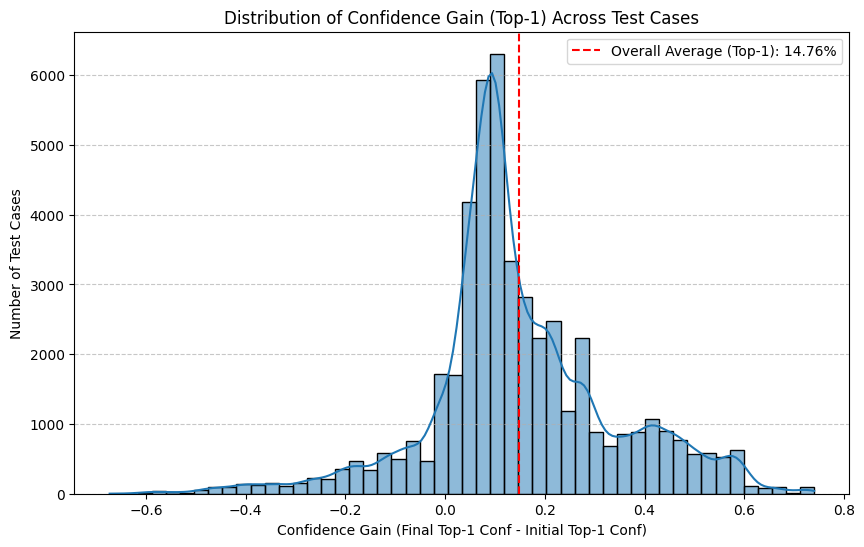

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out any NaN values or extremely large/small outliers if they exist
valid_confidence_gains_top1 = [g for g in all_confidence_gains_top1 if not np.isnan(g)]

plt.figure(figsize=(10, 6))
sns.histplot(valid_confidence_gains_top1, bins=50, kde=True)
plt.title('Distribution of Confidence Gain (Top-1) Across Test Cases')
plt.xlabel('Confidence Gain (Final Top-1 Conf - Initial Top-1 Conf)')
plt.ylabel('Number of Test Cases')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axvline(x=overall_average_confidence_gain_top1, color='r', linestyle='--', label=f'Overall Average (Top-1): {overall_average_confidence_gain_top1*100:.2f}%')
plt.legend()
plt.show()

In [28]:
highest_confidence_gain_top1 = np.max(all_confidence_gains_top1)
print(f"Highest Confidence Gain (Top-1) for a single case: {highest_confidence_gain_top1*100:.2f}%")

lowest_confidence_gain_top1 = np.min(all_confidence_gains_top1)
print(f"Lowest Confidence Gain (Top-1) for a single case: {lowest_confidence_gain_top1*100:.2f}%")

Highest Confidence Gain (Top-1) for a single case: 74.03%
Lowest Confidence Gain (Top-1) for a single case: -67.29%


### Interactive CLI User Flow

In [34]:
import numpy as np

# Ensure the engine is instantiated
if 'engine' not in locals():
    print("Instantiating MedAssistLocal engine...")
    engine = MedAssistLocal()

def run_cli_flow():
    print("\n--- Welcome to MedAssist CLI ---")
    print("Please enter your symptoms, separated by commas (e.g., 'fever, headache, nausea').")

    user_input_symptoms_str = input("Your symptoms: ")
    initial_symptoms = [s.strip().lower() for s in user_input_symptoms_str.split(',') if s.strip()]

    # Filter out symptoms not in our knowledge base
    valid_initial_symptoms = [s for s in initial_symptoms if s in engine.all_symptoms]
    invalid_initial_symptoms = [s for s in initial_symptoms if s not in engine.all_symptoms]

    if invalid_initial_symptoms:
        print(f"Warning: The following symptoms are not recognized and will be ignored: {', '.join(invalid_initial_symptoms)}")

    if not valid_initial_symptoms:
        print("No valid symptoms entered. Please try again with recognized symptoms.")
        return

    print(f"Considering initial symptoms: {', '.join(valid_initial_symptoms)}")

    # Get initial predictions
    initial_predictions = engine.get_top_3(valid_initial_symptoms)
    if initial_predictions:
        print("\nInitial Differential Diagnosis:")
        for i, (disease, conf) in enumerate(initial_predictions):
            print(f"{i+1}. {disease:<25} | Confidence: {conf*100:.2f}%")
    else:
        print("No initial predictions could be made.")

    # Get and suggest follow-up symptoms
    suggestions = engine.suggest_follow_up(valid_initial_symptoms)
    if suggestions:
        print(f"\nAI Suggestion: Are you also experiencing any of these? \n(Type 'yes' to add all, 'no' for none, or enter numbers/names of symptoms you are experiencing, e.g., '1, 3' or 'cough, nausea')")
        print("Suggested symptoms:")
        for j, s in enumerate(suggestions):
            print(f"  {j+1}. {s}")

        follow_up_response = input("Your response: ").strip().lower()

        additional_symptoms = []
        if follow_up_response == 'yes':
            # If 'yes', add all suggested symptoms up to a reasonable limit (e.g., 3)
            additional_symptoms = suggestions[:min(len(suggestions), 3)]
            print(f"Adding all suggested symptoms: {', '.join(additional_symptoms)}")
        elif follow_up_response == 'no':
            print("No suggested symptoms added.")
        else:
            selected_by_numbers = []
            # Check if input looks like comma-separated numbers
            if all(num.strip().isdigit() for num in follow_up_response.split(',')):
                try:
                    input_numbers = [int(num.strip()) for num in follow_up_response.split(',') if num.strip()]
                    for num in input_numbers:
                        if 1 <= num <= len(suggestions):
                            selected_by_numbers.append(suggestions[num-1])
                except ValueError:
                    # Should not happen if all are digits, but for safety
                    pass

            if selected_by_numbers:
                additional_symptoms = selected_by_numbers
                print(f"Adding confirmed symptoms (by number): {', '.join(additional_symptoms)}")
            else:
                # Fallback: Attempt to parse as symptom names (e.g., "cough, nausea")
                response_symptoms_by_name = [s.strip().lower() for s in follow_up_response.split(',') if s.strip()]
                additional_symptoms = [s for s in response_symptoms_by_name if s in suggestions and s in engine.all_symptoms]
                if additional_symptoms:
                    print(f"Adding confirmed symptoms (by name): {', '.join(additional_symptoms)}")
                else:
                    print("Could not parse your selection. No suggested symptoms added.")
    else:
        print("No further symptoms suggested at this time.")

    final_symptoms = list(set(valid_initial_symptoms + additional_symptoms)) # Use set to remove duplicates

    if len(final_symptoms) == len(valid_initial_symptoms):
        print("\nNo new symptoms were added. Final diagnosis based on initial symptoms.")
    else:
        print(f"\nConsidering all symptoms: {', '.join(final_symptoms)}")

    # Get final predictions
    final_predictions = engine.get_top_3(final_symptoms)
    if final_predictions:
        print("\nFinal Differential Diagnosis:")
        for i, (disease, conf) in enumerate(final_predictions):
            print(f"{i+1}. {disease:<25} | Confidence: {conf*100:.2f}%")
    else:
        print("No final predictions could be made.")

    print("\n--- End of MedAssist Session ---")

# Run the CLI flow
run_cli_flow()


--- Welcome to MedAssist CLI ---
Please enter your symptoms, separated by commas (e.g., 'fever, headache, nausea').
Your symptoms: vomiting, fever
Considering initial symptoms: vomiting, fever

Initial Differential Diagnosis:
1. otitis media              | Confidence: 7.40%
2. urinary tract infection   | Confidence: 6.47%
3. acute bronchospasm        | Confidence: 5.42%

AI Suggestion: Are you also experiencing any of these? 
(Type 'yes' to add all, 'no' for none, or enter numbers/names of symptoms you are experiencing, e.g., '1, 3' or 'cough, nausea')
Suggested symptoms:
  1. cough
  2. nausea
  3. sharp abdominal pain
Your response: 1,2
Adding confirmed symptoms (by number): cough, nausea

Considering all symptoms: cough, nausea, fever, vomiting

Final Differential Diagnosis:
1. meningitis                | Confidence: 67.61%
2. white blood cell disease  | Confidence: 10.90%
3. flu                       | Confidence: 9.16%

--- End of MedAssist Session ---
